In [74]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
str_parser = StrOutputParser()

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [75]:
from pydantic import BaseModel, Field
from typing import List

class llm_schema(BaseModel):
    tasks: List[str] = Field(description="List of tasks to be perfomred by the worker.")

llm_with_structuredOuput = llm_model.with_structured_output(llm_schema)
#llm_with_strcuredOuput.invoke("What is the capital of the france and what is it's popultation ?")

In [76]:
from typing import List, TypedDict

class graph_schema(TypedDict):
    query: str
    tasks: List[str]
    results: List[str]
    summary: str

Orchestrator node

In [77]:
def orchestrator_node(schema: graph_schema):

    user_query = schema["query"]

    template = ChatPromptTemplate.from_messages([
        ("system", "You are an orchestrator that breaks down a user quesry into tasks for the worker"),
        ("user", "user query is {query}. Please generate only one prompt for each task for the worker to perform")
    ])

    chain = template | llm_with_structuredOuput
    llm_repsonse = chain.invoke({"query" : user_query })

    return {"tasks" : llm_repsonse.tasks }

Worker node

In [78]:
def excute(query : str):
    response = llm_model.invoke(query).content
    return response

In [79]:
from concurrent.futures import ThreadPoolExecutor
def worker_node(schema : graph_schema):

    tasks = schema["tasks"]
    all_results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        result_futures = executor.map(excute, tasks)
        for result in result_futures:
            all_results.append(result)

    return {"results" : all_results}


Summary node

In [80]:
def summary_node(schema : graph_schema):

    results = schema["results"]

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You should summarizes the reslut from the worker"),
        ("user", "here is the result form the worker {worker_results}. Summarize it shortly")
    ])

    chain = prompt | llm_model | str_parser

    summary = chain.invoke({"worker_results" : results})
    return {"summary" : summary}

In [81]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("summary_node", summary_node)

graph.add_edge(START,"orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node","summary_node")
graph.add_edge("summary_node", END)

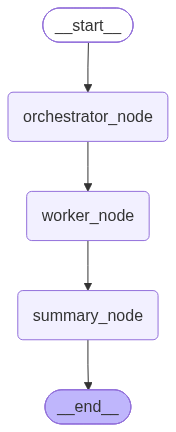

In [82]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [83]:
graph.invoke({
    "query" : "what is the capital of the India and what is the population of the Bengaluru",
    "tasks" : "",
    "results" : "",
    "summary" : ""
})

{'query': 'what is the capital of the India and what is the population of the Bengaluru',
 'tasks': ['State the capital city of India.',
  'Provide the latest population figure for Bengaluru (Bangalore), specifying whether this refers to the city proper, the metropolitan area, or the urban agglomeration, and include the year of the data and a reliable source.'],
 'results': ['New Delhi.',
  'I can do that. To give you the exact latest figure with a reliable source, please confirm:\n\n- Which geographic area do you want: \n  - city proper (within the city limits, e.g., BBMP area), \n  - metropolitan area/metro, or \n  - urban agglomeration (the broader contiguous urban area around Bengaluru)?\n\n- Do you want the most recent officially released figure (typically from the Census of India 2021 data, or the latest Urban Agglomeration data release), or a particular year?\n\nIf you confirm, I’ll fetch the latest figure for the chosen area, include the year, and cite a reliable source (with l